# Denoising & Outlier-Handling on Real 5G Data

Two real, fully-labelled / ground-truthed 5G datasets, **no synthetic injection**:

* **Tabular — 5G-NIDD** (Oulu 5G testbed): does cleaning the flow features improve supervised **attack classification** (RF / kNN)? Plus an unsupervised **detection diagnostic**.
* **Time-series — prepared_python** (web-server KPIs): does cleaning real natural outliers improve one-step **lat99 forecasting**? Blocked cross-validation.

Cleaning hyperparameters are chosen by **non-oracle Optuna** (TPE, seeded) on training folds only.

In [1]:
# ===== 0. Setup & config =====
import os, time, math, json, warnings
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.signal import savgol_coeffs
from scipy.stats import ttest_rel, false_discovery_control
from sklearn.ensemble import IsolationForest, RandomForestClassifier, RandomForestRegressor
from sklearn.neighbors import LocalOutlierFactor, KNeighborsClassifier, KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import f1_score, roc_auc_score, average_precision_score, mean_squared_error, mean_absolute_error
import optuna; optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore')

SEEDS      = [0, 1, 2, 3, 4]      # replicates
N_TAB      = 10_000               # stratified subsample of 5G-NIDD per seed
K_FOLDS    = 5                    # blocked time-series CV folds
N_TRIALS   = 20                   # Optuna trials per (method, probe, seed[, fold])
KNN_K      = 15
DOWNSTREAM = ['RF', 'kNN']
HP         = dict(sg_poly=3)      # Savitzky-Golay order fixed; all other HPs are Optuna-tuned
TAB_CSV    = 'Combined.csv'
TS_DIR     = '/home/test/prepared_python-20260608T130258Z-3-001/prepared_python'
RES, FIG   = 'results_real', 'figures_real'
os.makedirs(RES, exist_ok=True); os.makedirs(FIG, exist_ok=True)
np.random.seed(0)

/home/test/research_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Datasets

In [2]:
# ---- 5G-NIDD tabular: numeric flow features + binary attack label ----
LEAK = ['Unnamed: 0', 'Seq', 'Offset', 'Label', 'Attack Type', 'Attack Tool']
_full = pd.read_csv(TAB_CSV)
y_tab = (_full['Label'].astype(str).str.lower() != 'benign').astype(int).to_numpy()
_num  = _full.drop(columns=[c for c in LEAK if c in _full.columns]).select_dtypes(include=[np.number])
_num  = _num.replace([np.inf, -np.inf], np.nan); _num = _num.loc[:, _num.nunique(dropna=True) > 1]
X_tab = _num.to_numpy(float); TAB_FEATS = list(_num.columns)
print('5G-NIDD:', X_tab.shape, '| attack rate %.3f' % y_tab.mean(), '| features', len(TAB_FEATS))

5G-NIDD: (1215890, 39) | attack rate 0.607 | features 39


In [3]:
# ---- prepared_python time-series: multivariate KPI matrix, forecast next lat99 ----
_meta  = json.load(open(f'{TS_DIR}/meta.json')); TS_FEATS = _meta['target_cols']
TS_TGT = TS_FEATS.index('lat99_ms')
M_ts   = pd.concat([pd.read_csv(f'{TS_DIR}/train.csv'), pd.read_csv(f'{TS_DIR}/test_gt.csv')],
                   ignore_index=True)[TS_FEATS].to_numpy(float)
print('prepared_python series:', M_ts.shape, '| target = lat99_ms | NaN =', int(np.isnan(M_ts).sum()))

prepared_python series: (5787, 15) | target = lat99_ms | NaN = 0


## 2. Cleaning methods (hyperparameters supplied by the Optuna selector)

In [4]:
def _robust_z(c):
    m = np.median(c); d = np.median(np.abs(c - m))
    return np.zeros(len(c)) if d == 0 else np.abs((c - m) / (1.4826 * d))
def _flag_q(s, c): return s > np.quantile(s, 1 - c)
def _det_scores(kind, Z, struct, seed):
    if kind == 'Isolation Forest': return -IsolationForest(n_estimators=200, random_state=seed).fit(Z).score_samples(Z)
    if kind == 'LOF':
        nn = max(2, min(int(struct), len(Z) - 1)); l = LocalOutlierFactor(n_neighbors=nn); l.fit_predict(Z)
        return -l.negative_outlier_factor_
    k = int(max(1, min(struct, Z.shape[1] - 1))); p = PCA(n_components=k, random_state=seed).fit(Z)
    return np.sqrt(((Z - p.inverse_transform(p.transform(Z))) ** 2).sum(1))
def make_clf(probe, seed):
    if probe == 'RF': return RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=seed, n_jobs=-1)
    return Pipeline([('s', StandardScaler()), ('knn', KNeighborsClassifier(n_neighbors=KNN_K, weights='distance'))])
def make_reg(probe, seed):
    if probe == 'RF': return RandomForestRegressor(n_estimators=200, random_state=seed, n_jobs=-1)
    return Pipeline([('s', StandardScaler()), ('knn', KNeighborsRegressor(n_neighbors=KNN_K, weights='distance'))])
DET = {'Isolation Forest', 'LOF', 'PCA'}

# ---- Optuna search spaces (per method) and best-params -> hp dict ----
def _hp_space(trial, method):
    if method == 'Z-score':          return {'tau':  trial.suggest_float('tau', 2.0, 8.0)}
    if method == 'IQR':              return {'k':    trial.suggest_float('k', 1.0, 4.0)}
    if method == 'Savitzky-Golay':   return {'w':    trial.suggest_int('w', 5, 51, step=2)}
    if method == 'Isolation Forest': return {'contam': trial.suggest_float('contam', 0.005, 0.20)}
    if method == 'LOF':              return {'struct': trial.suggest_int('nn', 5, 50),   'contam': trial.suggest_float('contam', 0.005, 0.20)}
    if method == 'PCA':              return {'struct': trial.suggest_int('ncomp', 2, 8), 'contam': trial.suggest_float('contam', 0.005, 0.20)}
    return {}
def _hp_from_best(method, p):
    if method == 'Z-score':          return {'tau': p['tau']}
    if method == 'IQR':              return {'k': p['k']}
    if method == 'Savitzky-Golay':   return {'w': p['w']}
    if method == 'Isolation Forest': return {'contam': p['contam']}
    if method == 'LOF':              return {'struct': p['nn'],    'contam': p['contam']}
    if method == 'PCA':              return {'struct': p['ncomp'], 'contam': p['contam']}
    return {}

# ---- TABULAR cleaners (filters in place; detectors drop@train / impute@test) ----
def _zscore_tab(X, tau):
    Xc = X.copy()
    for j in range(X.shape[1]): Xc[_robust_z(X[:, j]) > tau, j] = np.median(X[:, j])
    return Xc
def _iqr_tab(X, k):
    Xc = X.copy()
    for j in range(X.shape[1]):
        q1, q3 = np.percentile(X[:, j], [25, 75]); iqr = q3 - q1
        Xc[:, j] = np.clip(X[:, j], q1 - k * iqr, q3 + k * iqr)
    return Xc
def _det_score_tab(method, X, struct, seed):
    return _det_scores(method, StandardScaler().fit_transform(X), struct, seed)
def clean_tab_train(method, X, y, seed, hp):
    if method in DET:
        fl = _flag_q(_det_score_tab(method, X, hp.get('struct'), seed), hp['contam']); Xk, yk = X[~fl], y[~fl]
        return (X.copy(), y) if (len(np.unique(yk)) < 2 or len(yk) < 10) else (Xk, yk)
    if method == 'Z-score': return _zscore_tab(X, hp['tau']), y
    if method == 'IQR':     return _iqr_tab(X, hp['k']), y
    return X.copy(), y
def clean_tab_test(method, X, seed, hp):
    if method in DET:
        fl = _flag_q(_det_score_tab(method, X, hp.get('struct'), seed), hp['contam']); Xc = X.copy()
        Xc[fl] = np.median(X[~fl] if (~fl).any() else X, axis=0); return Xc
    if method == 'Z-score': return _zscore_tab(X, hp['tau'])
    if method == 'IQR':     return _iqr_tab(X, hp['k'])
    return X.copy()

# ---- TIME-SERIES cleaners (causal; statistics/detectors fit on the train segment) ----
def _ffill(M, flag):
    M = M.copy(); idx = np.where(~flag, np.arange(len(M)), -1); np.maximum.accumulate(idx, out=idx)
    g = idx >= 0; M[g] = M[idx[g]]; return M
def clean_ts(method, Mtr, Mte, seed, hp):
    if method == 'NoClean': return Mtr.copy(), Mte.copy()
    if method == 'Z-score':
        med = np.median(Mtr, 0); mad = np.median(np.abs(Mtr - med), 0); mad[mad == 0] = 1; tau = hp['tau']
        def t(X):
            Y = X.copy()
            for j in range(X.shape[1]): Y[:, j] = _ffill(X[:, j:j+1], np.abs((X[:, j]-med[j])/(1.4826*mad[j])) > tau)[:, 0]
            return Y
        return t(Mtr), t(Mte)
    if method == 'IQR':
        k = hp['k']; q1 = np.percentile(Mtr, 25, 0); q3 = np.percentile(Mtr, 75, 0); iqr = q3 - q1
        lo, hi = q1 - k*iqr, q3 + k*iqr; return np.clip(Mtr, lo, hi), np.clip(Mte, lo, hi)
    if method == 'Savitzky-Golay':
        w = int(hp['w']); w = w if w % 2 == 1 else w + 1; cf = savgol_coeffs(w, HP['sg_poly'], pos=w-1, use='dot')
        def t(X):
            Y = X.astype(float).copy()
            if len(X) >= w:
                for j in range(X.shape[1]): Y[w-1:, j] = np.correlate(X[:, j], cf, mode='valid')
            return Y
        return t(Mtr), t(Mte)
    sc = StandardScaler().fit(Mtr); Ztr, Zte = sc.transform(Mtr), sc.transform(Mte)
    struct = hp.get('struct'); contam = hp['contam']
    if method == 'Isolation Forest':
        m_ = IsolationForest(n_estimators=200, random_state=seed).fit(Ztr); s_tr = -m_.score_samples(Ztr); s_te = -m_.score_samples(Zte)
    elif method == 'LOF':
        nn = max(2, min(int(struct), len(Ztr)-1)); l = LocalOutlierFactor(n_neighbors=nn, novelty=True).fit(Ztr)
        s_tr = -l.score_samples(Ztr); s_te = -l.score_samples(Zte)
    else:
        k = int(max(1, min(struct, Ztr.shape[1]-1))); p = PCA(n_components=k, random_state=seed).fit(Ztr)
        s_tr = np.sqrt(((Ztr - p.inverse_transform(p.transform(Ztr)))**2).sum(1)); s_te = np.sqrt(((Zte - p.inverse_transform(p.transform(Zte)))**2).sum(1))
    thr = np.quantile(s_tr, 1 - contam); return _ffill(Mtr, s_tr > thr), _ffill(Mte, s_te > thr)

TAB_METHODS = ['NoClean', 'Z-score', 'IQR', 'Isolation Forest', 'LOF', 'PCA']
TS_METHODS  = ['NoClean', 'Z-score', 'IQR', 'Savitzky-Golay', 'Isolation Forest', 'LOF', 'PCA']

## 3. Non-oracle Optuna hyperparameter selectors (training data only)

In [5]:
def _select_hp_tab(method, Xtr, ytr, probe, seed):
    if method == 'NoClean': return {}
    folds = list(StratifiedKFold(3, shuffle=True, random_state=seed).split(Xtr, ytr)); cache = {}
    def scache(tag, X, struct):
        key = (tag, struct)
        if key not in cache: cache[key] = _det_score_tab(method, X, struct, seed)
        return cache[key]
    def objective(trial):
        hp = _hp_space(trial, method); out = []
        for fi, (tr, va) in enumerate(folds):
            Xt, yt = Xtr[tr], ytr[tr]; Xv, yv = Xtr[va], ytr[va]
            if method in DET:
                st = hp.get('struct')
                fl = _flag_q(scache((fi, 'tr'), Xt, st), hp['contam']); Xc, yc = Xt[~fl], yt[~fl]
                if len(np.unique(yc)) < 2 or len(yc) < 10: Xc, yc = Xt, yt
                flv = _flag_q(scache((fi, 'va'), Xv, st), hp['contam']); Xvc = Xv.copy()
                Xvc[flv] = np.median(Xv[~flv] if (~flv).any() else Xv, axis=0)
            elif method == 'Z-score': Xc, yc, Xvc = _zscore_tab(Xt, hp['tau']), yt, _zscore_tab(Xv, hp['tau'])
            else:                     Xc, yc, Xvc = _iqr_tab(Xt, hp['k']),   yt, _iqr_tab(Xv, hp['k'])
            try: out.append(f1_score(yv, make_clf(probe, seed).fit(Xc, yc).predict(Xvc), average='macro'))
            except Exception: out.append(-1.0)
        return float(np.mean(out))
    s = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=seed)); s.optimize(objective, n_trials=N_TRIALS)
    return _hp_from_best(method, s.best_params)

def _select_hp_ts(method, seg_tr, probe, seed):
    if method == 'NoClean': return {}
    inner = int(0.75 * len(seg_tr))
    def objective(trial):
        hp = _hp_space(trial, method)
        Mi, Mv = clean_ts(method, seg_tr[:inner], seg_tr[inner:], seed, hp)
        Xt, yt = Mi[:-1], seg_tr[:inner][1:, TS_TGT]; Xv, yv = Mv[:-1], seg_tr[inner:][1:, TS_TGT]
        if len(Xt) < 10 or len(Xv) < 2: return float('inf')
        try: return math.sqrt(mean_squared_error(yv, make_reg(probe, seed).fit(Xt, yt).predict(Xv)))
        except Exception: return float('inf')
    s = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=seed)); s.optimize(objective, n_trials=N_TRIALS)
    return _hp_from_best(method, s.best_params)

## 4. Tabular experiment — attack classification + detection diagnostic

In [6]:
def run_tab_once(method, probe, seed):
    rng = np.random.default_rng(seed)
    pos = np.where(y_tab == 1)[0]; neg = np.where(y_tab == 0)[0]
    keep = np.concatenate([rng.choice(pos, N_TAB//2, replace=False), rng.choice(neg, N_TAB//2, replace=False)])
    X = X_tab[keep]; y = y_tab[keep]; med = np.nanmedian(X, 0); X = np.where(np.isnan(X), med, X)
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, stratify=y, random_state=seed)
    hp = _select_hp_tab(method, Xtr, ytr, probe, seed)
    t0 = time.perf_counter(); Xtr_k, ytr_k = clean_tab_train(method, Xtr, ytr, seed, hp); rt = (time.perf_counter()-t0)*1000
    Xte_k = clean_tab_test(method, Xte, seed, hp)
    clf = make_clf(probe, seed).fit(Xtr_k, ytr_k); pred = clf.predict(Xte_k)
    proba = clf.predict_proba(Xte_k)[:, 1] if hasattr(clf, 'predict_proba') else pred
    return dict(method=method, probe=probe, seed=seed, rep=seed, hp=str(hp),
                MacroF1=f1_score(yte, pred, average='macro'), ROC_AUC=roc_auc_score(yte, proba), Runtime=rt)

rows = []
for seed in SEEDS:
    for m in TAB_METHODS:
        for probe in DOWNSTREAM: rows.append(run_tab_once(m, probe, seed))
    print('tabular seed', seed, 'done')
tab_raw = pd.DataFrame(rows); tab_raw.to_csv(f'{RES}/raw_tabular.csv', index=False); tab_raw.head()

tabular seed 0 done
tabular seed 1 done
tabular seed 2 done
tabular seed 3 done
tabular seed 4 done


,method,probe,seed,rep,hp,MacroF1,ROC_AUC,Runtime
0,NoClean,RF,0,0,{},0.751395,0.868392,0.363689
1,NoClean,kNN,0,0,{},0.749361,0.857278,0.311153
2,Z-score,RF,0,0,{'tau': 6.291136198234517},0.751395,0.868305,9.839842
3,Z-score,kNN,0,0,{'tau': 7.350638004692478},0.749361,0.859204,9.430265
4,IQR,RF,0,0,{'k': 3.7109164570718183},0.720992,0.828594,11.266730


In [7]:
# Detection diagnostic: do unsupervised detectors flag the attacks? (no cleaning, score vs label)
drows = []
for seed in SEEDS:
    rng = np.random.default_rng(seed)
    keep = np.concatenate([rng.choice(np.where(y_tab==1)[0], N_TAB//2, replace=False),
                           rng.choice(np.where(y_tab==0)[0], N_TAB//2, replace=False)])
    X = X_tab[keep]; y = y_tab[keep]; med = np.nanmedian(X, 0); X = np.where(np.isnan(X), med, X)
    Z = StandardScaler().fit_transform(X)
    for kind, st in [('Isolation Forest', None), ('LOF', 20), ('PCA', 5)]:
        s = _det_scores(kind, Z, st, seed)
        drows.append(dict(method=kind, seed=seed, ROC_AUC=roc_auc_score(y, s), PR_AUC=average_precision_score(y, s)))
det_diag = pd.DataFrame(drows).groupby('method')[['ROC_AUC','PR_AUC']].agg(['mean','std'])
det_diag.to_csv(f'{RES}/detection_diagnostic.csv'); print('Unsupervised detection vs attack label:'); det_diag.round(3)

Unsupervised detection vs attack label:


ROC_AUC        PR_AUC       
                    mean    std   mean    std
method                                       
Isolation Forest   0.598  0.002  0.579  0.003
LOF                0.541  0.005  0.523  0.004
PCA                0.535  0.018  0.536  0.010

## 5. Time-series experiment — lat99 forecasting (blocked CV)

In [8]:
def ts_blocks(n, k):
    b = np.linspace(0, n, k + 1).astype(int); return [(b[i], b[i + 1]) for i in range(k)]
def run_ts_once(method, probe, seed, a, b, fold):
    seg = M_ts[a:b]; split = int(0.8 * len(seg))
    hp = _select_hp_ts(method, seg[:split], probe, seed)
    t0 = time.perf_counter(); Mtr, Mte = clean_ts(method, seg[:split], seg[split:], seed, hp); rt = (time.perf_counter()-t0)*1000
    Xtr, ytr = Mtr[:-1], seg[:split][1:, TS_TGT]; Xte, yte = Mte[:-1], seg[split:][1:, TS_TGT]
    if len(Xtr) < 10 or len(Xte) < 2: return None
    reg = make_reg(probe, seed).fit(Xtr, ytr); pred = reg.predict(Xte)
    return dict(method=method, probe=probe, seed=seed, fold=fold, rep=f'{seed}-{fold}', hp=str(hp),
                RMSE=math.sqrt(mean_squared_error(yte, pred)), MAE=mean_absolute_error(yte, pred), Runtime=rt)

rows = []; BLK = ts_blocks(len(M_ts), K_FOLDS)
for seed in SEEDS:
    for fold, (a, b) in enumerate(BLK):
        for m in TS_METHODS:
            for probe in DOWNSTREAM:
                r = run_ts_once(m, probe, seed, a, b, fold)
                if r: rows.append(r)
    print('time-series seed', seed, 'done  (x%d folds)' % K_FOLDS)
ts_raw = pd.DataFrame(rows); ts_raw.to_csv(f'{RES}/raw_timeseries.csv', index=False); ts_raw.head()

time-series seed 0 done  (x5 folds)
time-series seed 1 done  (x5 folds)
time-series seed 2 done  (x5 folds)
time-series seed 3 done  (x5 folds)
time-series seed 4 done  (x5 folds)


,method,probe,seed,fold,rep,hp,RMSE,MAE,Runtime
0,NoClean,RF,0,0,0-0,{},3106.968546,1477.673636,0.790959
1,NoClean,kNN,0,0,0-0,{},3197.937324,1582.565431,0.065716
2,Z-score,RF,0,0,0-0,{'tau': 3.988099038424637},3129.379957,1474.773398,1.853176
3,Z-score,kNN,0,0,0-0,{'tau': 3.736696045421455},3182.075850,1560.980998,1.052035
4,IQR,RF,0,0,0-0,{'k': 1.0755508492895256},3092.661824,1478.258485,0.959272


## 6. Tables

In [13]:
def agg(df, metrics, by='method'):
    g = df.groupby(['probe', by]); out = g[metrics].agg(['mean', 'std']).reset_index()
    out.columns = ['probe', by] + [f'{m}_{s}' for m in metrics for s in ('mean','std')]
    return out.sort_values(['probe', by]).reset_index(drop=True)
tab_tab = agg(tab_raw, ['MacroF1', 'ROC_AUC', 'Runtime']); tab_tab.to_csv(f'{RES}/table_tabular.csv', index=False)
ts_tab  = agg(ts_raw,  ['RMSE', 'MAE', 'Runtime']);        ts_tab.to_csv(f'{RES}/table_timeseries.csv', index=False)
print('TABULAR (attack classification):'); display(tab_tab.round(4))
print('TIME-SERIES (lat99 forecasting):'); display(ts_tab.round(2))

TABULAR (attack classification):


,probe,method,MacroF1_mean,MacroF1_std,ROC_AUC_mean,ROC_AUC_std,Runtime_mean,Runtime_std
0,RF,IQR,0.7098,0.0098,0.8137,0.0114,9.3359,1.1422
1,RF,Isolation Forest,0.7348,0.0112,0.8541,0.0093,278.3544,36.8349
2,RF,LOF,0.7355,0.0090,0.8537,0.0093,105.9464,8.1985
3,RF,NoClean,0.7379,0.0100,0.8572,0.0088,0.2977,0.0960
4,RF,PCA,0.7339,0.0087,0.8532,0.0078,13.6177,7.9024
5,RF,Z-score,0.7377,0.0099,0.8570,0.0089,10.1425,1.6883
6,kNN,IQR,0.7111,0.0092,0.8206,0.0113,8.2737,0.5500
7,kNN,Isolation Forest,0.7373,0.0082,0.8516,0.0104,267.8108,22.9274
8,kNN,LOF,0.7357,0.0099,0.8500,0.0125,106.0454,10.5130
9,kNN,NoClean,0.7385,0.0096,0.8531,0.0119,0.2512,0.0757


TIME-SERIES (lat99 forecasting):


,probe,method,RMSE_mean,RMSE_std,MAE_mean,MAE_std,Runtime_mean,Runtime_std
0,RF,IQR,6856.77,5233.61,4414.05,3921.87,1.09,0.20
1,RF,Isolation Forest,7134.26,5397.34,4704.52,4365.26,276.62,22.32
2,RF,LOF,7650.93,4829.40,5208.71,3633.56,38.99,10.89
3,RF,NoClean,6877.56,5204.50,4413.85,3914.98,0.10,0.18
4,RF,PCA,6306.76,4261.98,4158.73,3229.49,3.17,0.73
5,RF,Savitzky-Golay,5678.41,3518.69,3655.39,2753.28,1.08,0.24
6,RF,Z-score,6928.33,5308.17,4458.06,3961.02,1.65,0.29
7,kNN,IQR,5431.41,2549.03,2917.72,1474.99,0.72,0.38
8,kNN,Isolation Forest,6783.54,5212.12,3922.38,3488.30,281.80,39.42
9,kNN,LOF,5913.64,2571.86,3354.60,1792.46,38.24,11.43


## 7. Paired significance vs NoClean (per replicate, BH-FDR)

In [14]:
def paired_significance(raw, metric, higher_better):
    base, out = 'NoClean', []
    for probe, g in raw.groupby('probe'):
        ref = g[g.method == base][['rep', metric]].rename(columns={metric: '_r'})
        for m in sorted(set(g.method) - {base}):
            cur = g[g.method == m][['rep', metric]].rename(columns={metric: '_c'})
            mg = ref.merge(cur, on='rep').dropna()
            if len(mg) < 2: continue
            r = mg['_r'].to_numpy(); x = mg['_c'].to_numpy(); diff = (x - r) if higher_better else (r - x)
            try: t_p = float(ttest_rel(x, r).pvalue)
            except Exception: t_p = float('nan')
            out.append(dict(probe=probe, method=m, n_rep=len(diff), mean_improve=float(np.mean(diff)),
                            wins=f'{int((diff>0).sum())}/{len(diff)}', t_p=t_p))
    res = pd.DataFrame(out)
    if len(res): res['t_p_fdr'] = false_discovery_control(res['t_p'].fillna(1.0).to_numpy())
    return res.sort_values(['probe','method']).reset_index(drop=True)
sig_tab  = paired_significance(tab_raw, 'MacroF1', True)
sig_rmse = paired_significance(ts_raw,  'RMSE',    False)
sig_mae  = paired_significance(ts_raw,  'MAE',     False)
for nm, s in [('tabular_macrof1', sig_tab), ('timeseries_rmse', sig_rmse), ('timeseries_mae', sig_mae)]:
    s.to_csv(f'{RES}/sig_{nm}.csv', index=False)
print('TABULAR MacroF1 vs NoClean:'); display(sig_tab.round(4))
print('TIME-SERIES RMSE vs NoClean:'); display(sig_rmse.round(4))

TABULAR MacroF1 vs NoClean:


,probe,method,n_rep,mean_improve,wins,t_p,t_p_fdr
0,RF,IQR,5,-0.0281,0/5,0.0018,0.0092
1,RF,Isolation Forest,5,-0.0031,0/5,0.0173,0.0577
2,RF,LOF,5,-0.0024,0/5,0.0393,0.0981
3,RF,PCA,5,-0.0040,0/5,0.0490,0.0981
4,RF,Z-score,5,-0.0002,0/5,0.1778,0.2223
5,kNN,IQR,5,-0.0274,0/5,0.0017,0.0092
6,kNN,Isolation Forest,5,-0.0013,2/5,0.2241,0.2490
7,kNN,LOF,5,-0.0029,0/5,0.0846,0.1209
8,kNN,PCA,5,-0.0017,0/5,0.0626,0.1043
9,kNN,Z-score,5,-0.0005,1/5,0.4281,0.4281


TIME-SERIES RMSE vs NoClean:


,probe,method,n_rep,mean_improve,wins,t_p,t_p_fdr
0,RF,IQR,25,20.7843,15/25,0.3309,0.3610
1,RF,Isolation Forest,25,-256.7081,8/25,0.0327,0.0782
2,RF,LOF,25,-773.3768,6/25,0.0426,0.0782
3,RF,PCA,25,570.7922,16/25,0.0265,0.0782
4,RF,Savitzky-Golay,25,1199.1413,21/25,0.0055,0.0666
5,RF,Z-score,25,-50.7781,10/25,0.1793,0.2151
6,kNN,IQR,25,-33.1992,15/25,0.0522,0.0782
7,kNN,Isolation Forest,25,-1385.3301,9/25,0.0280,0.0782
8,kNN,LOF,25,-515.4316,5/25,0.0960,0.1280
9,kNN,PCA,25,-150.1345,11/25,0.0505,0.0782


## 8. Figures

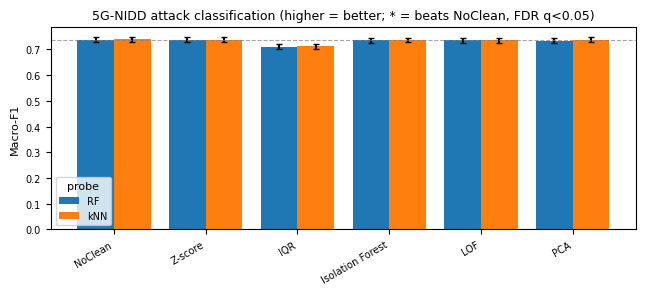

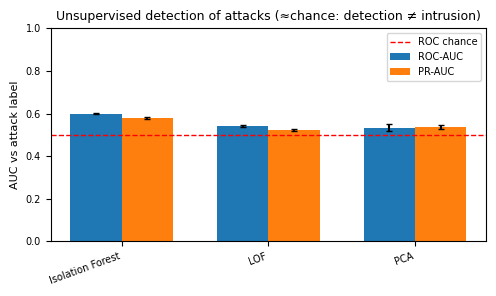

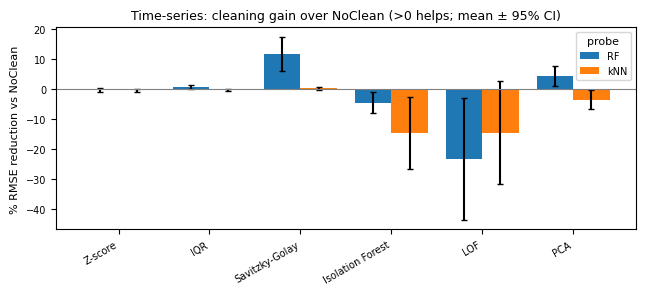

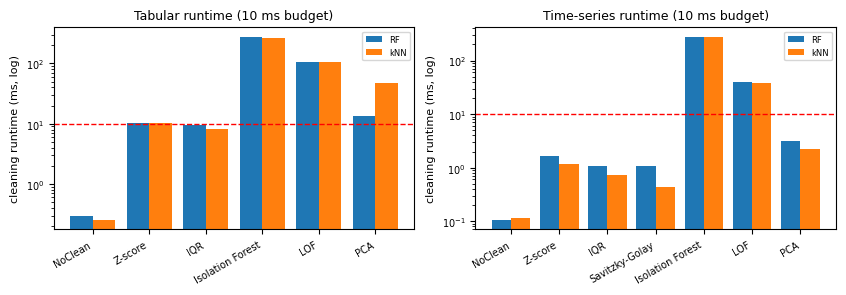

In [15]:
# ===== 8. Figures =====
import matplotlib as mpl
mpl.rcParams.update({"font.size": 8, "axes.titlesize": 9, "axes.labelsize": 8,
                     "xtick.labelsize": 7, "ytick.labelsize": 7, "legend.fontsize": 7, "savefig.dpi": 200})

def _sig_star(sig, probe):
    """method -> '*' when it SIGNIFICANTLY beats NoClean (mean_improve>0 and BH-FDR q<0.05)."""
    s = sig[sig.probe == probe]
    return {r['method']: ('*' if (r['mean_improve'] > 0 and r['t_p_fdr'] < 0.05) else '') for _, r in s.iterrows()}

# --- Fig 1: tabular Macro-F1 (+ NoClean line, + FDR-significance stars) ---
def fig_tab_macrof1():
    probes = sorted(tab_tab.probe.unique()); x = np.arange(len(TAB_METHODS)); w = 0.8 / len(probes)
    fig, ax = plt.subplots(figsize=(6.5, 3.0))
    for i, p in enumerate(probes):
        sub = tab_tab[tab_tab.probe == p].set_index('method')
        means = [sub.loc[m, 'MacroF1_mean'] if m in sub.index else 0 for m in TAB_METHODS]
        errs  = [sub.loc[m, 'MacroF1_std']  if m in sub.index else 0 for m in TAB_METHODS]
        ax.bar(x + i*w, means, w, yerr=errs, capsize=2, label=p)
        star = _sig_star(sig_tab, p)
        for j, m in enumerate(TAB_METHODS):
            if star.get(m): ax.text(x[j] + i*w, means[j] + (errs[j] or 0) + 0.004, '*', ha='center', fontsize=11)
    nc = tab_tab[tab_tab.probe == probes[0]].set_index('method').loc['NoClean', 'MacroF1_mean']
    ax.axhline(nc, ls='--', c='grey', lw=0.8, alpha=0.7)
    ax.set_xticks(x + 0.4 - w/2); ax.set_xticklabels(TAB_METHODS, rotation=30, ha='right')
    ax.set_ylabel('Macro-F1'); ax.set_title('5G-NIDD attack classification (higher = better; * = beats NoClean, FDR q<0.05)')
    ax.legend(title='probe'); fig.tight_layout(); fig.savefig(f'{FIG}/fig1_tab_macrof1.png', bbox_inches='tight'); plt.show()

# --- Fig 2: detection diagnostic (unsupervised detector AUC vs attack label; 0.5 = chance) ---
def fig_detection():
    dd = det_diag; methods = list(dd.index); x = np.arange(len(methods)); w = 0.35
    fig, ax = plt.subplots(figsize=(5.0, 3.0))
    ax.bar(x - w/2, dd[('ROC_AUC', 'mean')], w, yerr=dd[('ROC_AUC', 'std')], capsize=2, label='ROC-AUC')
    ax.bar(x + w/2, dd[('PR_AUC', 'mean')],  w, yerr=dd[('PR_AUC', 'std')],  capsize=2, label='PR-AUC')
    ax.axhline(0.5, ls='--', c='red', lw=1, label='ROC chance')
    ax.set_xticks(x); ax.set_xticklabels(methods, rotation=20, ha='right'); ax.set_ylim(0, 1)
    ax.set_ylabel('AUC vs attack label')
    ax.set_title('Unsupervised detection of attacks (≈chance: detection ≠ intrusion)')
    ax.legend(); fig.tight_layout(); fig.savefig(f'{FIG}/fig2_detection_diag.png', bbox_inches='tight'); plt.show()

# --- Fig 3: time-series cleaning GAIN over NoClean (paired % RMSE reduction; cancels fold heterogeneity) ---
def fig_ts_skill():
    base = 'NoClean'; probes = sorted(ts_raw.probe.unique()); methods = [m for m in TS_METHODS if m != base]
    x = np.arange(len(methods)); w = 0.8 / len(probes); fig, ax = plt.subplots(figsize=(6.5, 3.0))
    for i, p in enumerate(probes):
        g = ts_raw[ts_raw.probe == p]; ref = g[g.method == base][['rep', 'RMSE']].rename(columns={'RMSE': 'nc'})
        means, cis = [], []
        for m in methods:
            cur = g[g.method == m][['rep', 'RMSE']].rename(columns={'RMSE': 'cl'})
            mg = ref.merge(cur, on='rep').dropna()
            sk = (mg['nc'] - mg['cl']) / mg['nc'] * 100.0
            means.append(sk.mean()); cis.append(1.96 * sk.std() / max(1.0, np.sqrt(len(sk))))
        ax.bar(x + i*w, means, w, yerr=cis, capsize=2, label=p)
    ax.axhline(0, c='grey', lw=0.8)
    ax.set_xticks(x + 0.4 - w/2); ax.set_xticklabels(methods, rotation=30, ha='right')
    ax.set_ylabel('% RMSE reduction vs NoClean'); ax.set_title('Time-series: cleaning gain over NoClean (>0 helps; mean ± 95% CI)')
    ax.legend(title='probe'); fig.tight_layout(); fig.savefig(f'{FIG}/fig3_ts_skill.png', bbox_inches='tight'); plt.show()

# --- Fig 4: cleaning runtime (log ms) with the 10 ms near-RT RIC budget ---
def fig_runtime():
    fig, axes = plt.subplots(1, 2, figsize=(8.5, 3.0))
    for ax, (tab, methods, title) in zip(axes, [(tab_tab, TAB_METHODS, 'Tabular'), (ts_tab, TS_METHODS, 'Time-series')]):
        probes = sorted(tab.probe.unique()); x = np.arange(len(methods)); w = 0.8 / len(probes)
        for i, p in enumerate(probes):
            sub = tab[tab.probe == p].set_index('method')
            ax.bar(x + i*w, [max(sub.loc[m, 'Runtime_mean'], 1e-3) if m in sub.index else 1e-3 for m in methods], w, label=p)
        ax.axhline(10, ls='--', c='red', lw=1)   # 10 ms near-RT RIC budget
        ax.set_yscale('log'); ax.set_xticks(x + 0.4 - w/2); ax.set_xticklabels(methods, rotation=30, ha='right')
        ax.set_ylabel('cleaning runtime (ms, log)'); ax.set_title(f'{title} runtime (10 ms budget)'); ax.legend(fontsize=6)
    fig.tight_layout(); fig.savefig(f'{FIG}/fig4_runtime.png', bbox_inches='tight'); plt.show()

fig_tab_macrof1(); fig_detection(); fig_ts_skill(); fig_runtime()


In [12]:
import sys, sklearn, scipy
print('python', sys.version.split()[0], '| numpy', np.__version__, '| pandas', pd.__version__,
      '| sklearn', sklearn.__version__, '| scipy', scipy.__version__, '| optuna', optuna.__version__)

python 3.12.3 | numpy 2.4.4 | pandas 3.0.2 | sklearn 1.8.0 | scipy 1.17.1 | optuna 4.9.0
